In [1]:
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot as plt

In [ ]:
config = {}
config["data"] = {
    "parameter_range": (-5, 5),
    "std": 1,
    #"likelihood_prior_sampling_ratio": 1,
    "n_parameters": 1,
    "n_train": 70_000,
    "n_test": 15_000,
    "n_validation": 15_000
}
config["classifier"] = {
    "n_inputs": 1,
    "n_hidden_layers": 3,
    "n_units": 50,
    "activation": "relu"
}
config["training"] = {
    "learning_rate": 0.001,
    "batch_size": 128,
    "n_epochs": 50
}


#### Data:

In [4]:
generator = np.random.default_rng(0)
data_config = config["data"]
total_data_points = data_config["n_train"] + data_config["n_test"] + data_config["n_validation"]

#labels
labels = np.hstack((np.ones(total_data_points//2), np.zeros(total_data_points//2)))

#parameters
parameters_dependent = generator.uniform(low=data_config["parameter_range"][0], high=data_config["parameter_range"][1], size=total_data_points//2)
parameters_dependent = np.hstack((parameters_dependent, parameters_dependent))
parameters_independent = generator.uniform(low=data_config["parameter_range"][0], high=data_config["parameter_range"][1], size=total_data_points)

#data
data_S = generator.normal(loc=0, scale=data_config["std"], size=total_data_points//2)
data_B = generator.normal(loc=parameters_dependent[:total_data_points//2], scale=data_config["std"], size=total_data_points//2)
data = np.hstack((data_S, data_B))

#shuffle:
idx = np.arange(2*(total_data_points//2))
generator.shuffle(idx)
data, labels, parameters_dependent, parameters_independent = torch.tensor(data[idx]), torch.tensor(labels[idx]), torch.tensor(parameters_dependent[idx]), torch.tensor(parameters_independent[idx])

#split:
n_train, n_test, n_validation = data_config["n_train"], data_config["n_test"], data_config["n_validation"]
all_information = (data, labels, parameters_dependent, parameters_independent)
data_train, labels_train, parameters_dependent_train, parameters_independent_train = [x[:n_train] for x in all_information]
data_test, labels_test, parameters_dependent_test, parameters_independent_test = [x[n_train:n_train+n_test] for x in all_information]
data_validation, labels_validation, parameters_dependent_validation, parameters_independent_validation = [x[n_train+n_test:n_train+n_test+n_validation] for x in all_information]

print(data_train.shape, parameters_dependent_train.shape, parameters_independent_train.shape, labels_train.shape)
print(data_test.shape, parameters_dependent_test.shape, parameters_independent_test.shape, labels_test.shape)
print(data_validation.shape, parameters_dependent_validation.shape, parameters_independent_validation.shape, labels_validation.shape)

torch.Size([70000]) torch.Size([70000]) torch.Size([70000]) torch.Size([70000])
torch.Size([15000]) torch.Size([15000]) torch.Size([15000]) torch.Size([15000])
torch.Size([15000]) torch.Size([15000]) torch.Size([15000]) torch.Size([15000])


In [ ]:
generator = np.random.default_rng(0)
data_config = config["data"]
n_parameters = data_config["n_distinct_parameters"]
data_train, data_test, data_validation = np.array([]), np.array([]), np.array([])
labels_train, labels_test, labels_validation = np.array([]), np.array([]), np.array([])
parameters_train, prameters_test, parameters_validation = np.array([]), np.array([]), np.array([])
total_data_points = data_config["n_train"] + data_config["n_test"] + data_config["n_validation"]
for mean in np.linspace(data_config["mean_range"][0], data_config["mean_range"][1], n_parameters):
    #data:
    n_data = total_data_points//(2*n_parameters)
    data_0 = generator.normal(loc=mean, scale=data_config["std"], size=n_data)
    data_1 = generator.normal(loc=mean+2*data_config["std"], scale=data_config["std"], size=n_data)
    data = np.hstack((data_0, data_1))
    
    #labels:
    labels_0 = np.zeros(n_data)
    labels_1 = np.ones(n_data)
    labels = np.hstack((labels_0, labels_1))
    
    #parameters:
    parameters = np.full(2*n_data, mean)
    
    #split:
    n_train = data_config["n_train"]//n_parameters
    n_test = data_config["n_test"]//n_parameters
    n_validation = data_config["n_validation"]//n_parameters
    
    data_train = np.hstack((data_train, data[:n_train]))
    data_test = np.hstack((data_test, data[n_train:n_train+n_test]))
    data_validation = np.hstack((data_validation, data[n_train+n_test:]))
    
    parameters_train = np.hstack((parameters_train, parameters[:n_train]))
    prameters_test = np.hstack((prameters_test, parameters[n_train:n_train+n_test]))
    parameters_validation = np.hstack((parameters_validation, parameters[n_train+n_test:]))
    
    labels_train = np.hstack((labels_train, labels[:n_train]))
    labels_test = np.hstack((labels_test, labels[n_train:n_train+n_test]))
    labels_validation = np.hstack((labels_validation, labels[n_train+n_test:]))
    
#shuffle
def shuffle(arr):
    idx = np.arange(arr.shape[0])
    generator.shuffle(idx)
    return arr[idx]

data_train, data_test, data_validation = shuffle(data_train), shuffle(data_test), shuffle(data_validation)
parameters_train, prameters_test, parameters_validation = shuffle(parameters_train), shuffle(prameters_test), shuffle(parameters_validation)
labels_train, labels_test, labels_validation = shuffle(labels_train), shuffle(labels_test), shuffle(labels_validation)

print(data_train.shape, parameters_train.shape, labels_train.shape)
print(data_test.shape, prameters_test.shape, labels_test.shape)
print(data_validation.shape, parameters_validation.shape, labels_validation.shape)

#### Classifier:

In [5]:
class BinaryClassifier(nn.Module):
    def __init__(self, n_inputs):
        super(BinaryClassifier, self).__init__()
        input_layer = [nn.Linear(n_inputs, config["classifier"]["n_units"]), nn.ReLU()]
        hidden_layers = []
        for _ in range(config["classifier"]["n_hidden_layers"]):
            hidden_layers += [nn.Linear(config["classifier"]["n_units"], config["classifier"]["n_units"]), nn.ReLU()]
        output_layer = [nn.Linear(config["classifier"]["n_units"], 1), nn.Sigmoid()]
        self.model = nn.Sequential(*(input_layer + hidden_layers + output_layer))    
        
    def forward(self, x):
        return self.model(x)

#### Training:

In [6]:
def train(model, data_train, parameters_train, labels_train, data_validation, parameters_validation, labels_validation):    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    
    train_dataset = torch.utils.data.TensorDataset(data_train, parameters_train, labels_train)
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=config["training"]["batch_size"], shuffle=True)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=config["training"]["learning_rate"])
    criterion = nn.BCELoss()
    
    results = {
        "train_loss": [],
        "val_loss": [],
        "val_accuracy": [],
        "val_auc": []
    }
    
    for epoch in range(config["training"]["n_epochs"]):
        model.train()
        epoch_loss = 0
        for batch_data, batch_parameters, batch_labels in train_loader:
            batch_data, batch_parameters, batch_labels = batch_data.to(device).float().unsqueeze(1), batch_parameters.to(device).float().unsqueeze(1), batch_labels.to(device).float().unsqueeze(1)
            inputs = torch.cat((batch_data, batch_parameters), dim=1)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, batch_labels)
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
        
        results["train_loss"] += [epoch_loss / len(train_loader)]
        
        model.eval()
        with torch.no_grad():
            val_data, val_parameters, val_labels = data_validation.to(device).float().unsqueeze(1), parameters_validation.to(device).float().unsqueeze(1), labels_validation.to(device).float().unsqueeze(1)
            val_inputs = torch.cat((val_data, val_parameters), dim=1)
            val_outputs = model(val_inputs)
            val_loss = criterion(val_outputs, val_labels)
            val_accuracy = ((val_outputs >= 0.5).float() == val_labels).float().mean()
            val_auc = roc_auc_score(val_labels.cpu(), val_outputs.cpu())

        results["val_loss"] += [val_loss.item()]
        results["val_accuracy"] += [val_accuracy.item()]
        results["val_auc"] += [val_auc]
        print(f"Epoch {epoch+1}/{config['training']['n_epochs']}, Loss: {results["train_loss"][-1]}, Val Loss: {val_loss.item():.4f}, Val Acc: {val_accuracy.item():.4f}, Val AUC: {val_auc:.4f}")
                
    return model, results

#### Run:

prior-dependent:

In [23]:
model_dependent = BinaryClassifier(n_inputs=config["classifier"]["n_inputs"]+config["data"]["n_parameters"])
model_dependent, results_dependent = train(model_dependent, data_train, parameters_dependent_train, labels_train, data_validation, parameters_dependent_validation, labels_validation)

Epoch 1/50, Loss: 0.33213682832295105, Val Loss: 0.3053, Val Acc: 0.8423, Val AUC: 0.9389
Epoch 2/50, Loss: 0.3105199629035685, Val Loss: 0.3032, Val Acc: 0.8425, Val AUC: 0.9391
Epoch 3/50, Loss: 0.30966386588552536, Val Loss: 0.3021, Val Acc: 0.8425, Val AUC: 0.9395
Epoch 4/50, Loss: 0.30910869629226173, Val Loss: 0.3044, Val Acc: 0.8415, Val AUC: 0.9382
Epoch 5/50, Loss: 0.30926620916649017, Val Loss: 0.3008, Val Acc: 0.8425, Val AUC: 0.9396
Epoch 6/50, Loss: 0.30858327350298276, Val Loss: 0.3024, Val Acc: 0.8405, Val AUC: 0.9392
Epoch 7/50, Loss: 0.3085065705521233, Val Loss: 0.3016, Val Acc: 0.8415, Val AUC: 0.9391
Epoch 8/50, Loss: 0.30848580887592253, Val Loss: 0.3016, Val Acc: 0.8409, Val AUC: 0.9394
Epoch 9/50, Loss: 0.3086188897027394, Val Loss: 0.3018, Val Acc: 0.8405, Val AUC: 0.9394
Epoch 10/50, Loss: 0.30829587802154707, Val Loss: 0.3021, Val Acc: 0.8408, Val AUC: 0.9392
Epoch 11/50, Loss: 0.3082358488435065, Val Loss: 0.3018, Val Acc: 0.8409, Val AUC: 0.9395
Epoch 12/50,

prior-independent:

In [24]:
model_independent = BinaryClassifier(n_inputs=config["classifier"]["n_inputs"]+config["data"]["n_parameters"])
model_independent, results_independent = train(model_independent, data_train, parameters_independent_train, labels_train, data_validation, parameters_independent_validation, labels_validation)

Epoch 1/50, Loss: 0.4735689814827342, Val Loss: 0.4689, Val Acc: 0.7737, Val AUC: 0.8365
Epoch 2/50, Loss: 0.45722081440022483, Val Loss: 0.4543, Val Acc: 0.7846, Val AUC: 0.8411
Epoch 3/50, Loss: 0.4561224938310696, Val Loss: 0.4511, Val Acc: 0.7875, Val AUC: 0.8419
Epoch 4/50, Loss: 0.45547944389052103, Val Loss: 0.4499, Val Acc: 0.7873, Val AUC: 0.8417
Epoch 5/50, Loss: 0.45609944170746114, Val Loss: 0.4521, Val Acc: 0.7847, Val AUC: 0.8418
Epoch 6/50, Loss: 0.45542576053678663, Val Loss: 0.4521, Val Acc: 0.7871, Val AUC: 0.8410
Epoch 7/50, Loss: 0.4554275996179424, Val Loss: 0.4508, Val Acc: 0.7867, Val AUC: 0.8422
Epoch 8/50, Loss: 0.45520826198937037, Val Loss: 0.4508, Val Acc: 0.7868, Val AUC: 0.8406
Epoch 9/50, Loss: 0.45516134686836157, Val Loss: 0.4550, Val Acc: 0.7830, Val AUC: 0.8401
Epoch 10/50, Loss: 0.4550216718827131, Val Loss: 0.4501, Val Acc: 0.7875, Val AUC: 0.8417
Epoch 11/50, Loss: 0.45520221304414044, Val Loss: 0.4525, Val Acc: 0.7864, Val AUC: 0.8419
Epoch 12/50,

#### Plots:

In [18]:
def plot(results, title):
    fig, ax = plt.subplots(1, 2, figsize=(9, 3))
    ax[0].plot(results["train_loss"], label="Train Loss")
    ax[0].plot(results["val_loss"], label="Validation Loss")
    ax[0].set_xlabel("Epoch")
    ax[0].set_ylabel("Loss")
    ax[0].set_ylim(0.2, 0.5)
    ax[0].set_title(title)
    ax[0].legend()
    ax[1].plot(results["val_accuracy"], label="Validation Accuracy")
    ax[1].plot(results["val_auc"], label="Validation AUC")
    ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("Metric")
    ax[1].set_ylim(0.7, 1)
    ax[1].set_title(title)
    ax[1].legend()
    plt.tight_layout()

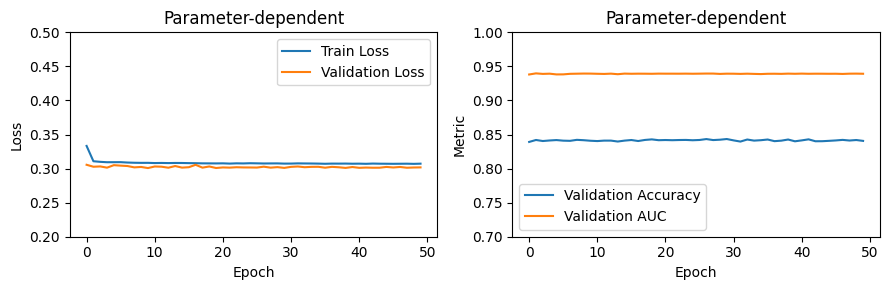

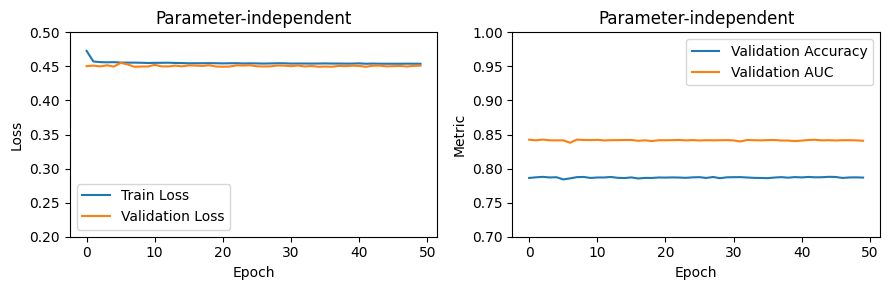

In [19]:
plot(results_dependent, "Parameter-dependent")
plot(results_independent, "Parameter-independent")

#### Testing:

In [20]:
def test_model(model, data_test, parameters_test, labels_test):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    with torch.no_grad():
        model.eval()
        data_test, parameters_test, labels_test = data_test.to(device).float().unsqueeze(1), parameters_test.to(device).float().unsqueeze(1), labels_test.to(device).float().unsqueeze(1)
        inputs = torch.cat((data_test, parameters_test), dim=1)
        outputs = model(inputs)
        test_loss = nn.BCELoss()(outputs, labels_test)
        test_accuracy = ((outputs >= 0.5).float() == labels_test).float().mean()
        test_auc = roc_auc_score(labels_test.cpu(), outputs.cpu())
    print(f"Test Loss: {test_loss.item():.4f}, Test Acc: {test_accuracy.item():.4f}, Test AUC: {test_auc:.4f}")
    return test_loss.item(), test_accuracy.item(), test_auc    

In [25]:
test_results_dependent = test_model(model_dependent, data_test, parameters_dependent_test, labels_test)
test_results_independent = test_model(model_independent, data_test, parameters_independent_test, labels_test)

Test Loss: 0.3058, Test Acc: 0.8389, Test AUC: 0.9370
Test Loss: 0.4501, Test Acc: 0.7850, Test AUC: 0.8402
